# CHALLENGE: Plot the monthly mean of daily maximum temperature

Use all the skills and resources you have learnt today to complete the notebook below.

In [2]:
from earthkit import data as ekd
from earthkit import geo as ekg
from earthkit import plots as ekp
from earthkit import transforms as ekt

## Load some data from the CDS

Download 2m temperature data from the
[ERA5 single levels data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)
collection in the [Climate Data Store](https://cds.climate.copernicus.eu) using `earthkit.data`.

Please note that you require a CDS API key to access the CDS data.

Ideally they should be in your ~/.cdsapirc file, if they are not you will
be prompted for the credentials when executing the following cell.
For more details on setting up your CDS credentials please see the
[How to API page](https://cds.climate.copernicus.eu/how-to-api) in the CDS.

In [4]:
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": "reanalysis",
    "variable": "2m_temperature",
    "year": "2020",
    "month": "01",
    "day": [f"{i:02d}" for i in range(1, 32)],
    "time": [f"{i:02d}:00" for i in range(24)],
    "area": [65, -10, 45, 5],  # North, West, South, East
}

# Use earthkit data to submit the above request to the CDS
data = ekd.from_source("cds", dataset, request)
data.to_xarray(time_dims=["valid_time"])

2026-05-07 09:11:02,664 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-07 09:11:02,665 INFO Request ID is b7ebd25f-15f9-4e91-9b7a-19870d092305
2026-05-07 09:11:02,774 INFO status has been updated to accepted
2026-05-07 09:11:36,271 INFO status has been updated to running
2026-05-07 09:12:19,129 INFO status has been updated to successful


4d541ec589551ea4ba91d55db29ff8f7.grib:   0%|          | 0.00/7.09M [00:00<?, ?B/s]

<xarray.Dataset> Size: 29MB
Dimensions:     (valid_time: 744, latitude: 81, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 648B 65.0 64.75 64.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 488B -10.0 -9.75 -9.5 -9.25 ... 4.5 4.75 5.0
Data variables:
    2t          (valid_time, latitude, longitude) float64 29MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Get some country geometries from the gisco inventory available in the `earthkit.geo`.

Hint: see [`gisco.countries` method](https://earthkit-geo.readthedocs.io/en/latest/autoapi/earthkit/geo/gisco/countries.html#earthkit.geo.gisco.countries) in API reference.

In [5]:
countries = ekg.gisco.countries().to_geopandas()
countries

,CNTR_ID,COUNTRY_UR,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,STAT_CODE,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,BJ,BEN,Bénin,Benin,Bénin,BEN,UN Member State,Porto-Novo (constitutional),OA,F,F,F,Benin,"POLYGON ((3.48347 11.43839, 3.71987 11.12125, ..."
1,BL,BLM,Saint-Barthélemy,Saint Barthélemy,Saint-Barthélemy,BLM,FR Territory,Gustavia,OA,F,F,F,St. Barthélemy,"POLYGON ((-62.86166 17.89421, -62.81385 17.925..."
2,BM,BMU,Bermuda,Bermuda,Bermudes,BMU,UK Non-Self-Governing Territory,Hamilton,OA,F,F,F,Bermuda,"POLYGON ((-64.97732 32.22906, -64.78311 32.262..."
3,BN,BRN,Brunei,Brunei,Brunei,BRN,UN Member State,Bandar Seri Begawan,OA,F,F,F,Brunei,"MULTIPOLYGON (((114.72274 4.05122, 114.65183 4..."
4,BO,BOL,Wuliwya-Volívia-Bulivya-Bolivia,Bolivia,Bolivie,BOL,UN Member State,La Paz (adm.),OA,F,F,F,Bolivien,"POLYGON ((-65.35734 -9.7276, -65.29293 -9.8551..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,XG,XXG,Ilemi Triangle (Disputed Territory),Ilemi Triangle,None,XG,Sovereignty unsettled,None,UA,F,F,F,None,"MULTIPOLYGON (((35.33777 4.9938, 35.32323 4.91..."
259,BZ,BLZ,Belize,Belize,Belize,BLZ,UN Member State,Belmopan,OA,F,F,F,Belize,"MULTIPOLYGON (((-88.38817 18.36539, -88.3262 1..."
260,XXW,XXW,Belize/Guatemala,Belize/Guatemala,Belize/Guatemala,XXW,Sovereignty unsettled,None,UA,F,F,F,Belize/Guatemala,"MULTIPOLYGON (((-88.91273 15.90006, -89.22759 ..."
261,XXT,XXT,Sapodilla Cayes,Sapodilla Cayes,cayes de Sapodilla,XXT,Sovereignty unsettled,None,UA,F,F,F,Sapodilla Cayes,"POLYGON ((-88.27868 16.13781, -88.25644 16.159..."


Use earthkit transforms to compute the monthly mean of the daily maximum temperature.

Hint: see [Daily and monthly statistics](../earthkit-transforms/01b-temporal-aggregations-daily-monthly.ipynb) example.

In [9]:
daily_max = ekt.temporal.daily_max(data)
monthly_mean_daily_max = ekt.temporal.monthly_mean(daily_max)
monthly_mean_daily_max

<xarray.Dataset> Size: 41kB
Dimensions:                  (forecast_reference_time: 1, latitude: 81,
                              longitude: 61)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2020...
  * latitude                 (latitude) float64 648B 65.0 64.75 ... 45.25 45.0
  * longitude                (longitude) float64 488B -10.0 -9.75 ... 4.75 5.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 40kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Plot the monthly mean as gridded data using `earthkit.plots`.

Hint: see [Introduction to earthkit-plots](../earthkit-plots/ekp-1-introduction.ipynb)

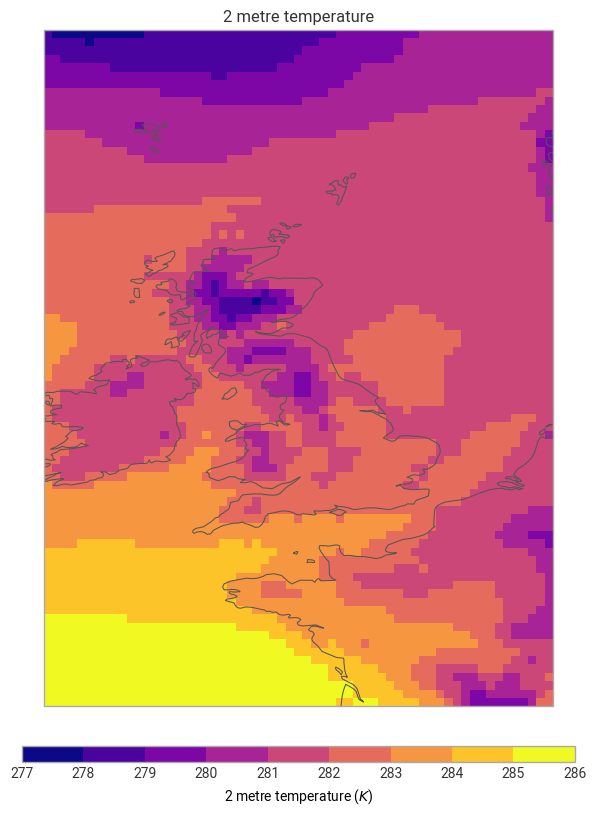

In [15]:
chart = ekp.geo.pcolormesh(
    monthly_mean_daily_max
)

Aggregate this over your country geometries using `earthkit.transforms`, ensure to weight by latitude.

Hint: see [Reducing data-cubes over geometries](../earthkit-transforms/02b-reduce-data-over-geometries.ipynb)

In [12]:
country_mean = ekt.spatial.reduce(
    daily_max, countries, how="mean",
    extra_reduce_dims=["forecast_reference_time"],  # Reduce also in the time dimension
    weights="latitude",  # Weight the mean with latitude
)

Plot the country aggregated data with `choropleth` method in `earthkit.plots`.

Hint: it will be easier if you add the data to your countries geopandas object, see [Reducing data-cubes over geometries](../earthkit-transforms/02b-reduce-data-over-geometries.ipynb)

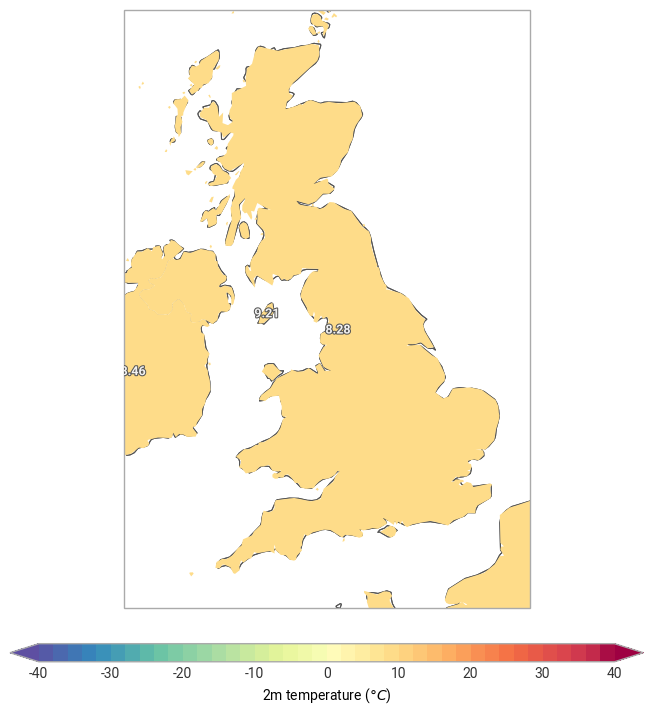

In [14]:
# Add the reduced data back to the original GeoDataFrame for plotting
countries = countries.assign(t2m=country_mean['2t'])
choropleth = ekp.geo.choropleth(
    countries,
    z="t2m",
    domain="UK",
    metadata={"units": "K", "long_name": "2m temperature"},
    units="celsius",
    labels="{t2m:0.2f}",
)
choropleth.coastlines()
choropleth.borders()
choropleth.show()